# Machine Learning Assignment - G00415845
 
## Workflow
1. Data Loading & Understanding
2. Data Preprocessing
3. Train / Validation / Test Split
4. Model Training
5. Hyperparameter Tuning (Cross-Validation)
6. Model Comparison
7. Final Model Selection
8. Test Set Evaluation (ONLY ONCE)
9. Conclusion

## 1. Setup

This section initialises the environment, imports required libraries, 
and sets a fixed random seed to ensure reproducibility.

In [ ]:
# Core
import numpy as np
import pandas as pd

# Image processings
from PIL import Image

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models (we will use these later)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Misc
import time
import os
from datetime import datetime
from pathlib import Path


# TensorFlow (for deep learning models)
import tensorflow as tf

In [17]:
RANDOM_STATE = 415845
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

### Helper Functions - Recording Results

1. Logs

2. Table

In [ ]:
os.makedirs("logs", exist_ok=True)

def log_run(model_name, params, start_time, end_time, train_acc, val_acc, notes=""):
    
    duration = end_time - start_time
    
    log_file = "logs/experiment_log.txt"
    
    entry = f"""
========================================
Time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
Model: {model_name}
Parameters: {params}
Training Time (s): {duration:.2f}
Train Accuracy: {train_acc:.4f}
Validation Accuracy: {val_acc:.4f}
Notes: {notes}
========================================
"""
    
    with open(log_file, "a") as f:
        f.write(entry)

In [ ]:
results_df = pd.DataFrame(columns=[
    "Model",
    "Parameters",
    "Train Accuracy",
    "Validation Accuracy",
    "Training Time (s)",
    "Overfitting (Train - Val)",
    "Notes"
])

## 2. Data Loading and Understanding - Garbage Dataset

The dataset consists of images of different types of waste materials.
Each class is stored in a separate folder.

I will:
- Load images
- Convert to feature vectors
- Create labels
- Inspect dataset structure

In [23]:
data_dir = Path("../data/garbage/garbage")

print("Dataset exists:", data_dir.exists())
print("Dataset path:", data_dir.resolve())

Dataset exists: True
Dataset path: C:\Users\norak\Desktop\ML-Assingment G00415845\data\garbage\garbage


In [24]:
# Class distribution
class_names = [d.name for d in data_dir.iterdir() if d.is_dir()]
class_counts = {}

for class_name in class_names:
    class_path = data_dir / class_name
    image_files = [f for f in class_path.iterdir() if f.is_file()]
    class_counts[class_name] = len(image_files)

class_counts

{'battery': 756,
 'biological': 699,
 'cardboard': 1411,
 'clothes': 1892,
 'glass': 1736,
 'metal': 930,
 'paper': 1336,
 'plastic': 1597,
 'shoes': 1449,
 'trash': 453}

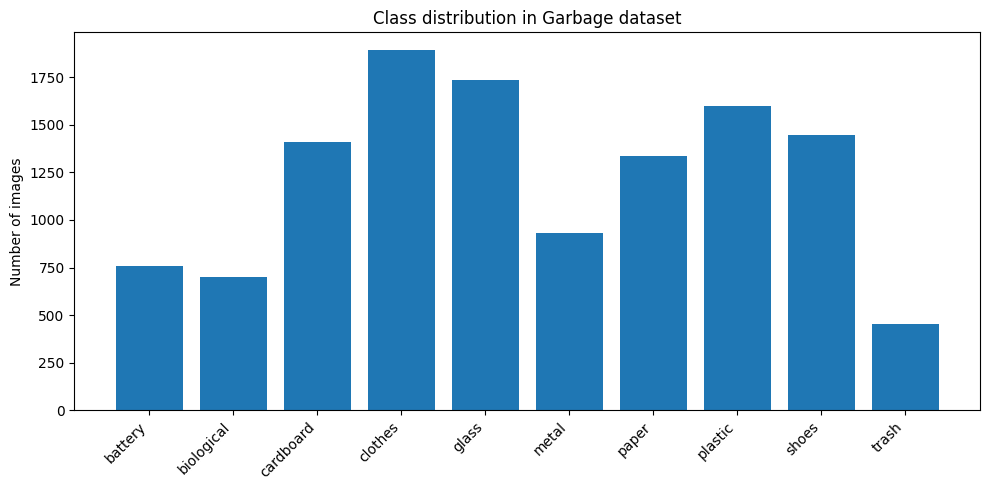

In [25]:
# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution in Garbage dataset")
plt.tight_layout()
plt.show()

In [27]:
# Sample some images from the dataset
images_batch, labels_batch = next(iter(full_ds))

plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    plt.title(full_ds.class_names[labels_batch[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'full_ds' is not defined

In [28]:
# Check pixel value range and dtype

print("Pixel dtype:", images_batch.dtype)
print("Min pixel value:", tf.reduce_min(images_batch).numpy())
print("Max pixel value:", tf.reduce_max(images_batch).numpy())

NameError: name 'images_batch' is not defined

In [ ]:

IMAGE_SIZE = (128, 128) # will resize all images to this size for consistency
BATCH_SIZE = 32 # will use a batch size of 32 for training our models


In [ ]:
# Check for corrupted images

bad_files = []

for class_name in class_names:
    class_path = data_dir / class_name
    for file_path in class_path.iterdir():
        try:
            with Image.open(file_path) as img:
                img.verify()  # check if image is valid
        except Exception:
            bad_files.append(file_path)

print("Number of corrupted images:", len(bad_files))

Number of corrupted images: 0
